In [3]:
import random
import json
import numpy as np
import matplotlib.pyplot as plt

from mdps import GridWorld

random.seed(1234)

with open("data/mazes_0-11.json") as f:
    init_maze = json.load(f)

    init_maze = {k[:-2]: v for k, v in init_maze.items()}

with open("data/mazes_12-15.json") as f:
    memory_maze = json.load(f)

maze = {**init_maze, **memory_maze}
default_gray = 0.1


def viz(grid: GridWorld, start=None, colors=None, labels=False, ax=None):
    import matplotlib.pyplot as plt

    if not ax:
        fig, ax = plt.subplots()

    for s in grid.states:
        ax.add_patch(plt.Rectangle(s, 1, 1, ec="gray", fc="white", lw=0))

    if start:
        ax.add_patch(plt.Circle((start[0] + 0.5, start[1] + 0.5), 0.25, fc="none", ec="blue"))

    artists = {}
    for i, o in enumerate(grid.obstacles):
        c = "black" if not colors else colors[i]
        n = grid.obstacle_names[i]
        if n not in artists:
            artists[n] = []
        for s in o:
            artist = ax.add_patch(plt.Rectangle(s, 1, 1, ec=c, fc=c, lw=0))
            artists[n].append(artist)
            continue

    ax.add_patch(plt.Rectangle(grid.goal, 1, 1, ec="yellow", fc="green", lw=0, zorder=3))

    if labels:
        for i, o in zip(grid.obstacle_names, grid.obstacles):
            center = np.array(o).mean(axis=0)
            plt.text(center[0], center[1], f"{i}", c="red", fontsize=12, fontweight="bold")

    plt.plot([0, grid.width], [grid.height, grid.height], "k-", lw=2)
    plt.plot([grid.width, grid.width], [0, grid.height], "k-", lw=2)
    plt.plot([0, grid.width], [0, 0], "k-", lw=2)
    plt.plot([0, 0], [0, grid.height], "k-", lw=2)

    ax.autoscale_view()
    plt.axis("off")
    plt.axis("equal")

    return artists

<Figure size 640x480 with 0 Axes>

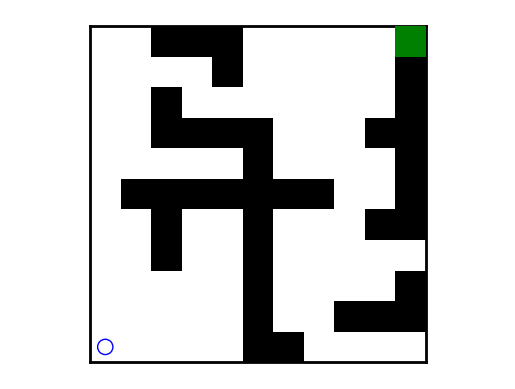

In [2]:
gridstr = maze["grid-11"]
D = len(gridstr)
startidx = "".join(reversed(gridstr)).index("S")
goalidx = "".join(reversed(gridstr)).index("G")
start = (startidx % D, startidx // D)
goal = (goalidx % D, goalidx // D)

grid = GridWorld.from_string(gridstr)
plt.figure()
# grid.viz(start=start)
viz(grid, start=start)

plt.savefig("../figures/example_gridworld.svg", bbox_inches="tight", pad_inches=0)

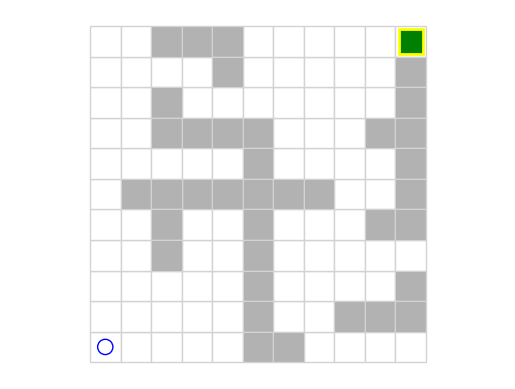

In [18]:
gridstr = maze["grid-11"]
D = len(gridstr)
startidx = "".join(reversed(gridstr)).index("S")
goalidx = "".join(reversed(gridstr)).index("G")
start = (startidx % D, startidx // D)
goal = (goalidx % D, goalidx // D)

grid = GridWorld.from_string(gridstr)
grid.viz(colors=[(0, 0, 0, 0.3) if name in {"#"} else (0, 0, 0, 0.3) for name in grid.obstacle_names], start=start)

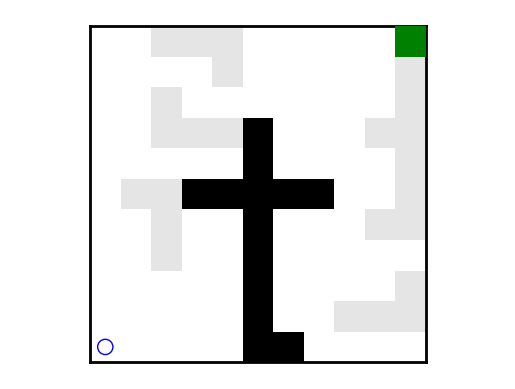

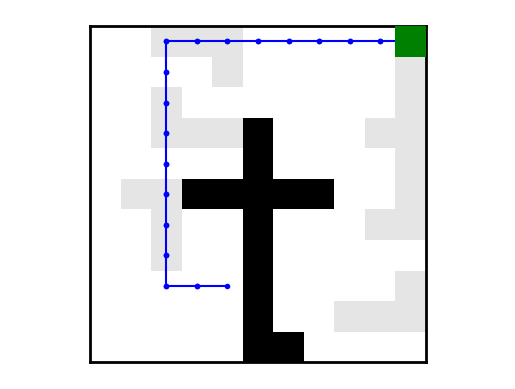

In [ ]:
def manhattan(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def draw_path(path):
    for p1, p2 in zip(path[:-1], path[1:]):
        plt.plot([p1[0] + 0.5, p2[0] + 0.5], [p1[1] + 0.5, p2[1] + 0.5], ".-", color="blue")


def draw_grid_construal(grid, construal):
    return viz(
        grid,
        colors=[
            (0, 0, 0, default_gray) if name not in construal else (0, 0, 0, 1)
            for name in grid.obstacle_names
        ],
    )
gridstr = maze["grid-11"]
D = len(gridstr)
startidx = "".join(reversed(gridstr)).index("S")
goalidx = "".join(reversed(gridstr)).index("G")
start = (startidx % D, startidx // D)
goal = (goalidx % D, goalidx // D)

grid = GridWorld.from_string(gridstr)
# grid.viz(start=start)
viz(grid, colors=[(0, 0, 0, 1) if name in {"#", "1"} else (0, 0, 0, 0.1) for name in grid.obstacle_names], start=start)
pathtmp = [
    (4, 2),
    (3, 2),
    (2, 2),
    (2, 3),
    (2, 4),
    (2, 5),
    (2, 6),
    (2, 7),
    (2, 8),
    (2, 9),
    (2, 10),
    (3, 10),
    (4, 10),
    (5, 10),
    (6, 10),
    (7, 10),
    (8, 10),
    (9, 10),
    (10, 10),
]
draw_grid_construal(grid, ["#", "1"])
draw_path(pathtmp)
# draw_grid_construal(grid, {"#", "1"})

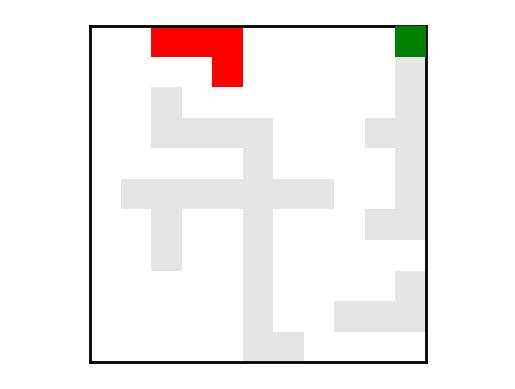

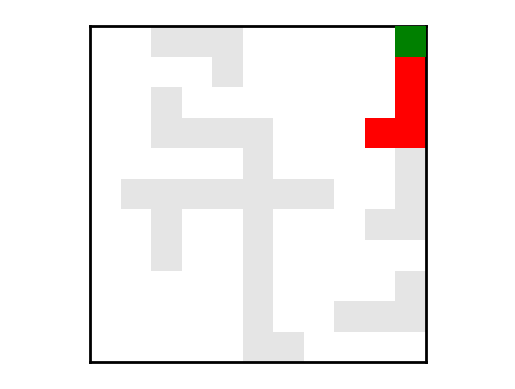

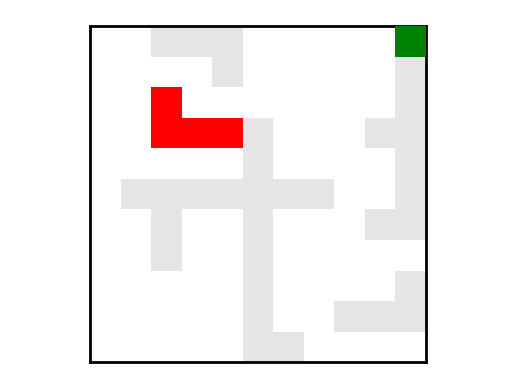

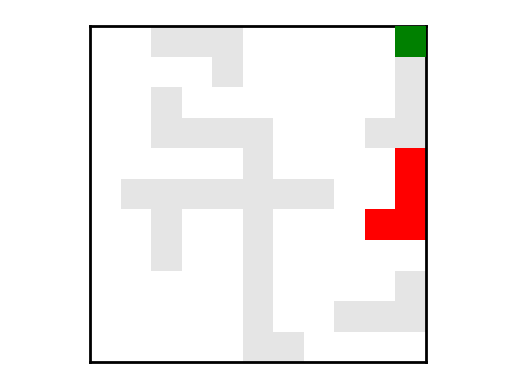

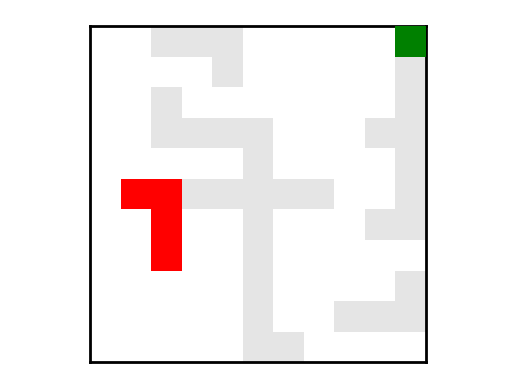

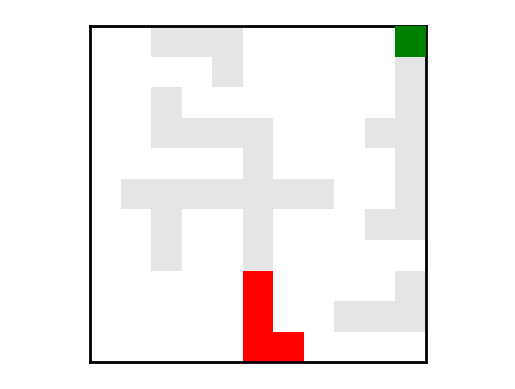

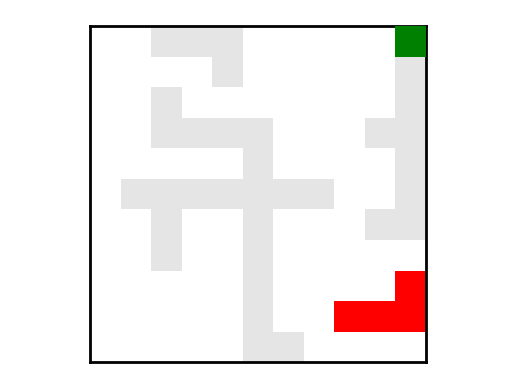

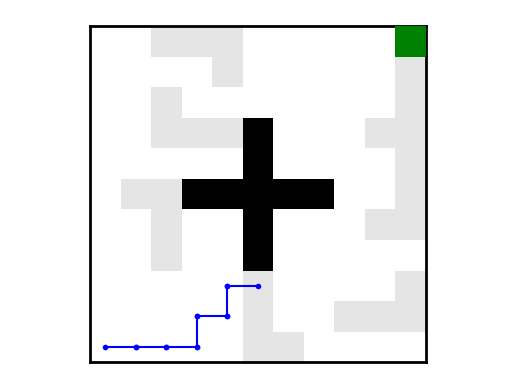

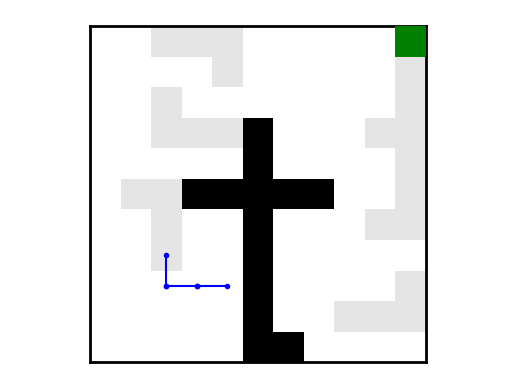

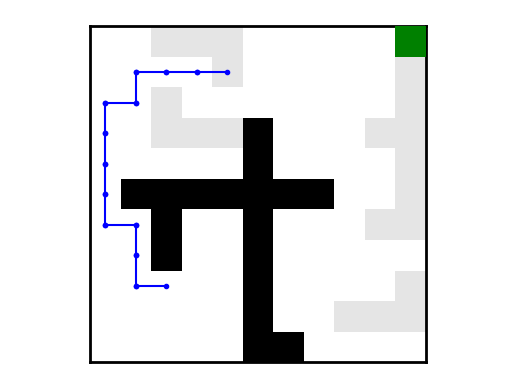

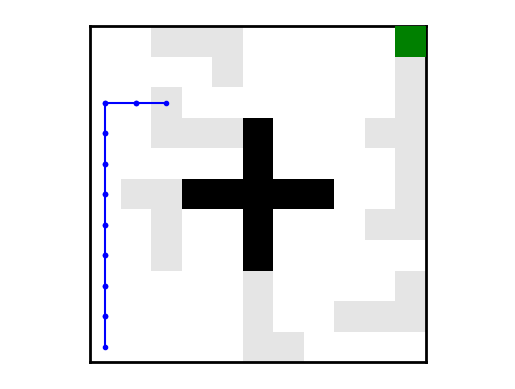

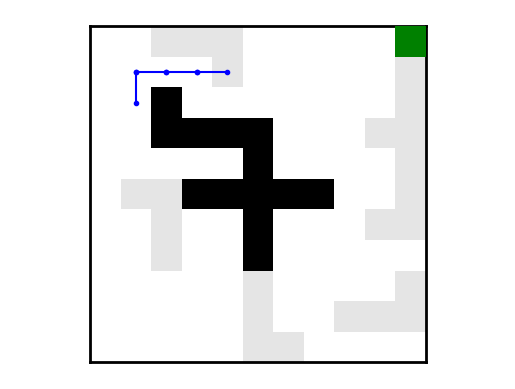

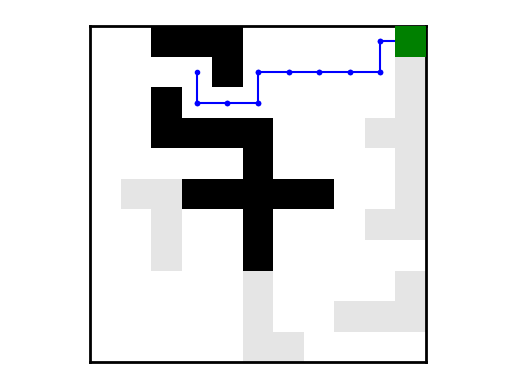

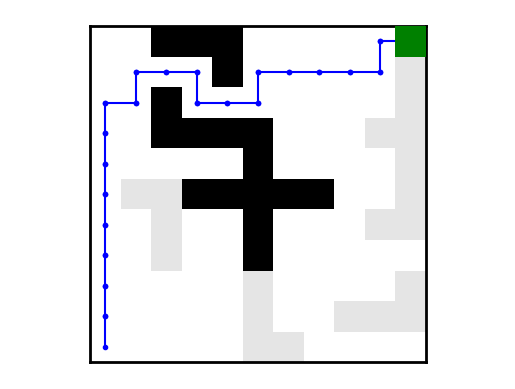

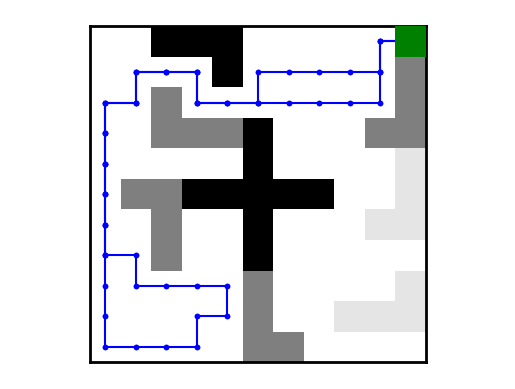

In [5]:
import jit


def manhattan(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def draw_path(path):
    for p1, p2 in zip(path[:-1], path[1:]):
        plt.plot([p1[0] + 0.5, p2[0] + 0.5], [p1[1] + 0.5, p2[1] + 0.5], ".-", color="blue")


def draw_grid_construal(grid, construal):
    return viz(
        grid,
        colors=[
            (0, 0, 0, default_gray) if name not in construal else (0, 0, 0, 1)
            for name in grid.obstacle_names
        ],
    )

for obj in grid.obstacle_names:
    if obj == "#":
        continue
    artists = draw_grid_construal(grid, [obj])
    for a in artists[obj]:
        a.set_color((1, 0, 0, 1))
    plt.savefig(f"../figures/grid_perception_{obj}.svg", bbox_inches="tight", pad_inches=0)

# %%
random.seed(1234)
# path1_1, _ = jit.astar(
#     grid,
#     (0, 0),
#     (10, 10),
#     set([grid.obstacle_names.index("#")]),
#     0.1,
#     0.1,
#     grid.manhattan,
#     False,
#     True,
# )
path1_1 = [
    (0, 0),
    (1, 0),
    (2, 0),
    (3, 0),
    (3, 1),
    (4, 1),
    (4, 2),
    (5, 2),
]
draw_grid_construal(grid, ["#"])
plt.axis("equal")
draw_path(path1_1)
plt.savefig("../figures/jit_gridmodel_path0_step0.svg")

path1_2 = [
    (4, 2),
    (3, 2),
    (2, 2),
    (2, 3),
]
draw_grid_construal(grid, ["#", "1"])
plt.axis("equal")
draw_path(path1_2)
plt.savefig("../figures/jit_gridmodel_path0_step1.svg")


path1_3 = [
    (2, 2),
    (1, 2),
    (1, 3),
    (1, 4),
    (0, 4),
    (0, 5),
    (0, 6),
    (0, 7),
    (0, 8),
    (1, 8),
    (1, 9),
    (2, 9),
    (3, 9),
    (4, 9),
]
draw_grid_construal(grid, ["#", "1", "0"])
plt.axis("equal")
draw_path(path1_3)
plt.savefig("../figures/jit_gridmodel_path0_step2.svg")

# %%

path1 = (
    [(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1), (4, 2), (3, 2)]
    + [
        (2, 2),
        (1, 2),
        (1, 3),
        (0, 3),
        (0, 4),
        (0, 5),
        (0, 6),
        (0, 7),
        (0, 8),
        (1, 8),
        (1, 9),
        (2, 9),
    ]
    + [(3, 9), (3, 8), (4, 8), (5, 8), (6, 8), (7, 8), (8, 8), (9, 8), (9, 9), (9, 10), (10, 10)]
)


# %%
random.seed(1234)
path2_1 = [
    (0, 0),
    (0, 1),
    (0, 2),
    (0, 3),
    (0, 4),
    (0, 5),
    (0, 6),
    (0, 7),
    (0, 8),
    (1, 8),
    (2, 8),
]
viz(
    grid,
    colors=[
        (0, 0, 0, default_gray) if name not in ["#"] else (0, 0, 0, 1)
        for name in grid.obstacle_names
    ],
)

plt.axis("equal")
draw_path(path2_1)
plt.savefig("../figures/jit_gridmodel_path1_step0.svg")

path2_2 = [
    (1, 8),
    (1, 9),
    (2, 9),
    (3, 9),
    (4, 9),
]
draw_grid_construal(grid, ["#", "3"])
plt.axis("equal")
draw_path(path2_2)
plt.savefig("../figures/jit_gridmodel_path1_step1.svg")

path2_3 = [
    (3, 9),
    (3, 8),
    (4, 8),
    (5, 8),
    (5, 9),
    (6, 9),
    (7, 9),
    (8, 9),
    (9, 9),
    (9, 10),
    (10, 10),
]
draw_grid_construal(grid, ["#", "3", "4"])
plt.axis("equal")
draw_path(path2_3)
plt.savefig("../figures/jit_gridmodel_path1_step2.svg")

colors = {
    "#": (0, 0, 0, 1),
    "1": (0, 0, 0, 0.5),
    "3": (0, 0, 0, 0.5),
    "4": (0, 0, 0, 1),
    "6": (0, 0, 0, 0.5),
    "0": (0, 0, 0, 0.5),
}
path2 = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8)] + [
    (1, 8),
    (1, 9),
    (2, 9),
    (3, 9),
    (3, 8),
    (4, 8),
    (5, 8),
    (5, 9),
    (6, 9),
    (7, 9),
    (8, 9),
    (9, 9),
    (9, 10),
    (10, 10),
]

draw_grid_construal(grid, ["#", "3", "4"])
plt.axis("equal")
draw_path(path2)
plt.savefig("../figures/jit_gridmodel_accum0.svg")


viz(grid, colors=[colors.get(name, (0, 0, 0, default_gray)) for name in grid.obstacle_names])
# grid.viz(colors=[colors.get(name, (0, 0, 0, default_gray)) for name in grid.obstacle_names])
plt.axis("equal")
draw_path(path1)
draw_path(path2)
plt.savefig("../figures/jit_gridmodel_accum1.svg")
